# MWE 40 - DRP-317 Berea 3-D ROI PNM comparison

This notebook collects the existing DRP-317 Berea pore-network estimates from
`18_mwe_drp317_berea_raw_porosity_perm` and prepares them for comparison with
the map-resistor and FEM micro-continuum study in notebook 41.

Scientific scope and assumptions:

- the PNM rows use the scanned `256 x 256 x 256` ROI from notebook 18
- the RAW binary convention is `0 = void/pore`, selected by comparison with the
  published porosity reference
- the experimental comparison target is `Kabs = 121 mD`
- no extraction is rerun here by default; this notebook is a lightweight
  reproducibility and visualization layer over the existing DRP-317 Berea
  outputs

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.paths import data_path, project_root

plt.ioff()

In [2]:
# User-editable inputs
sample_name = "DRP-317 Berea"
sample_stem = "Berea_2d25um"
raw_relpath = Path("drp-317") / "Berea_2d25um_binary.raw"
voxel_size_um = 2.25
voxel_size_m = voxel_size_um * 1.0e-6

experimental_porosity_pct = 18.96
experimental_kabs_mD = 121.0
experimental_kabs_rel_error = 0.10

input_dir = data_path() / "drp-317"
pnm_directional_path = input_dir / f"{sample_stem}_kabs_directional.csv"
pnm_summary_path = input_dir / f"{sample_stem}_kabs_summary_by_backend.csv"
estimated_properties_path = input_dir / f"{sample_stem}_estimated_properties.csv"
roi_scan_path = input_dir / f"{sample_stem}_roi_scan.csv"

output_dir = (
    project_root() / "notebooks" / "outputs" / "40_mwe_drp317_berea_roi_pnm_comparison"
)
output_dir.mkdir(parents=True, exist_ok=True)

M2_PER_MD = 9.869233e-16

## Load existing PNM outputs

In [3]:
for required_path in [
    pnm_directional_path,
    pnm_summary_path,
    estimated_properties_path,
]:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required Berea PNM output: {required_path}")

pnm_directional = pd.read_csv(pnm_directional_path)
pnm_summary = pd.read_csv(pnm_summary_path)
estimated_properties = pd.read_csv(estimated_properties_path)
roi_scan = pd.read_csv(roi_scan_path) if roi_scan_path.exists() else pd.DataFrame()

roi_origin = None
roi_shape = (256, 256, 256)
roi_porosity_pct = np.nan
if not roi_scan.empty:
    best_row = roi_scan.iloc[0]
    roi_origin = tuple(int(v) for v in str(best_row["origin"]).strip("()").split(","))
    roi_porosity_pct = float(best_row["porosity_pct"])

input_summary = pd.DataFrame(
    [
        {"quantity": "sample", "value": sample_name, "units": "-"},
        {
            "quantity": "RAW path",
            "value": str(input_dir / raw_relpath.name),
            "units": "-",
        },
        {"quantity": "voxel size", "value": voxel_size_m, "units": "m"},
        {"quantity": "ROI origin", "value": str(roi_origin), "units": "voxels"},
        {"quantity": "ROI shape", "value": str(roi_shape), "units": "voxels"},
        {"quantity": "ROI porosity from scan", "value": roi_porosity_pct, "units": "%"},
        {
            "quantity": "experimental porosity",
            "value": experimental_porosity_pct,
            "units": "%",
        },
        {"quantity": "experimental Kabs", "value": experimental_kabs_mD, "units": "mD"},
    ]
)

display(input_summary)
display(pnm_directional)
display(pnm_summary)

,quantity,value,units
0,sample,DRP-317 Berea,-
1,RAW path,/Users/dtvolpatto/Work/voids/examples/data/drp...,-
2,voxel size,0.000002,m
3,ROI origin,"(0, 744, 0)",voxels
4,ROI shape,"(256, 256, 256)",voxels
5,ROI porosity from scan,21.318674,%
6,experimental porosity,18.96,%
7,experimental Kabs,121.0,mD


,backend,backend_label,axis,k_m2,k_mD,n_pores,n_throats,conductance_model,mass_balance_error,reference_viscosity
0,native_maximal_ball,Native maximal-ball,x,8.936247e-14,90.546519,963.0,1651.0,generic_poiseuille,1.434516e-20,0.000889
1,native_maximal_ball,Native maximal-ball,y,7.254374e-14,73.504943,963.0,1651.0,generic_poiseuille,2.318513e-20,0.000889
2,native_maximal_ball,Native maximal-ball,z,7.400727e-14,74.987863,963.0,1651.0,generic_poiseuille,1.789934e-20,0.000889
3,porespy,PoreSpy snow2,x,1.430193e-13,144.914263,2062.0,3373.0,generic_poiseuille,4.029550e-20,0.000889
4,porespy,PoreSpy snow2,y,1.329440e-13,134.705474,2062.0,3373.0,generic_poiseuille,4.372137e-20,0.000889
5,porespy,PoreSpy snow2,z,1.383019e-13,140.134387,2062.0,3373.0,generic_poiseuille,4.935590e-20,0.000889
6,prego,PREGO,x,2.775306e-13,281.207868,1501.0,3301.0,generic_poiseuille,5.701217e-20,0.000889
7,prego,PREGO,y,2.355568e-13,238.677965,1501.0,3301.0,generic_poiseuille,5.047745e-20,0.000889
8,prego,PREGO,z,2.658124e-13,269.334438,1501.0,3301.0,generic_poiseuille,3.565274e-20,0.000889


,backend,backend_label,k_mean_mD,k_mean_m2,k_rms_mD,k_rms_m2,axis_count,aggregate_kabs_mD,aggregate_kabs_m2
0,native_maximal_ball,Native maximal-ball,79.679775,7.863783e-14,80.051709,7.900490e-14,3.0,80.051709,7.900490e-14
1,porespy,PoreSpy snow2,139.918041,1.380884e-13,139.980183,1.381497e-13,3.0,139.980183,1.381497e-13
2,prego,PREGO,263.073423,2.596333e-13,263.682938,2.602348e-13,3.0,263.682938,2.602348e-13


## Visual PNM comparison

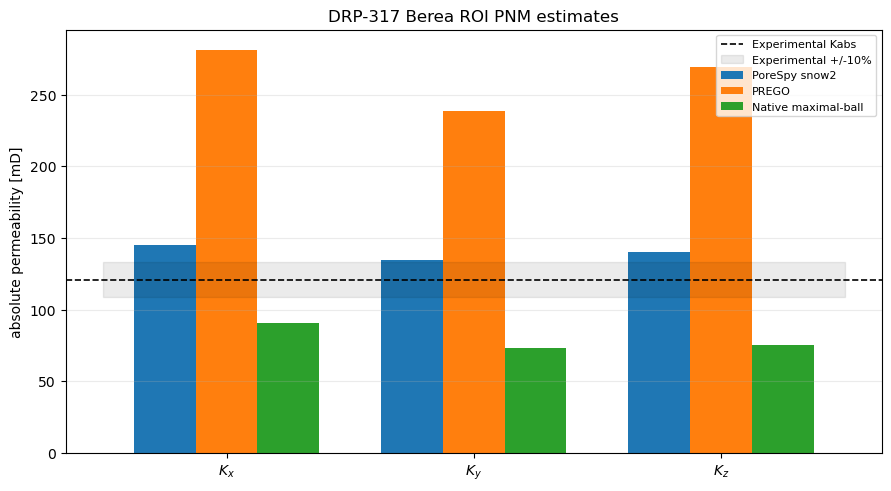

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/40_mwe_drp317_berea_roi_pnm_comparison/drp317_berea_roi_pnm_directional.png')

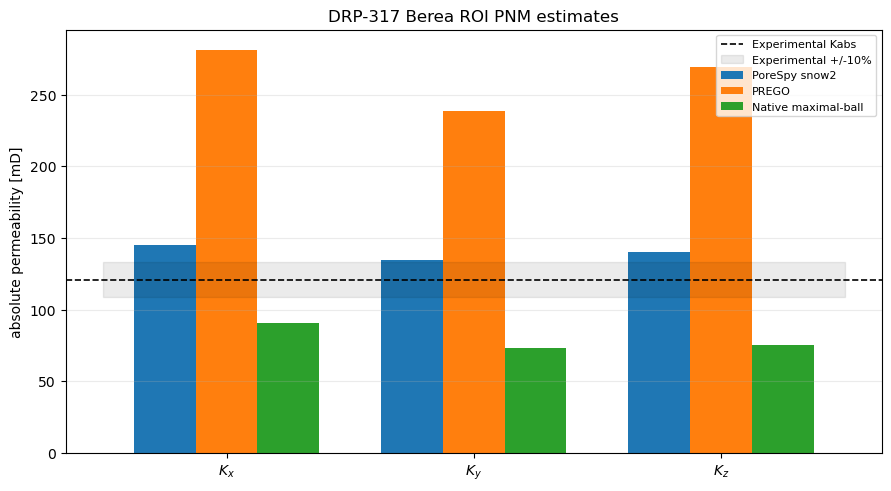

In [4]:
plot_df = pnm_directional.copy()
axis_order = ["x", "y", "z"]
method_order = ["PoreSpy snow2", "PREGO", "Native maximal-ball"]
available_methods = [
    method for method in method_order if method in set(plot_df["backend_label"])
]

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
bar_width = 0.75 / max(len(available_methods), 1)
x_positions = np.arange(len(axis_order), dtype=float)

for method_index, method in enumerate(available_methods):
    subset = plot_df[plot_df["backend_label"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(float(match.iloc[0]["k_mD"]) if not match.empty else np.nan)
    offset = (method_index - 0.5 * (len(available_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.axhline(
    experimental_kabs_mD,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Experimental Kabs",
)
ax.fill_between(
    [-0.5, len(axis_order) - 0.5],
    experimental_kabs_mD * (1.0 - experimental_kabs_rel_error),
    experimental_kabs_mD * (1.0 + experimental_kabs_rel_error),
    color="black",
    alpha=0.08,
    label="Experimental +/-10%",
)
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("absolute permeability [mD]")
ax.set_title("DRP-317 Berea ROI PNM estimates")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=8)

pnm_plot_path = output_dir / "drp317_berea_roi_pnm_directional.png"
fig.savefig(pnm_plot_path, dpi=200)
display(fig)
pnm_plot_path

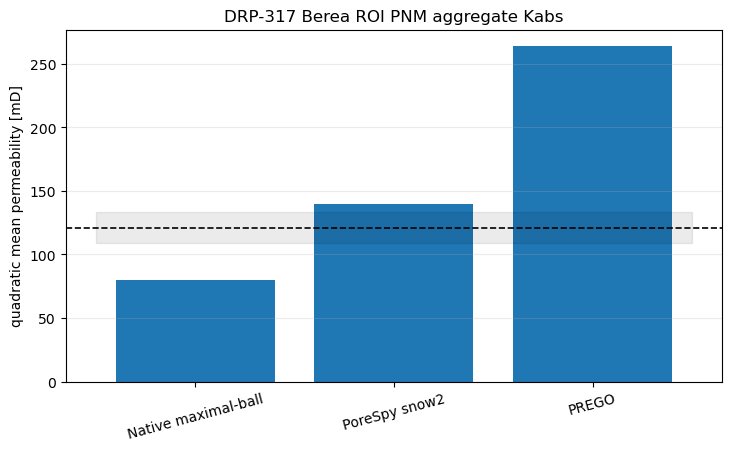

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/40_mwe_drp317_berea_roi_pnm_comparison/drp317_berea_roi_pnm_aggregate.png')

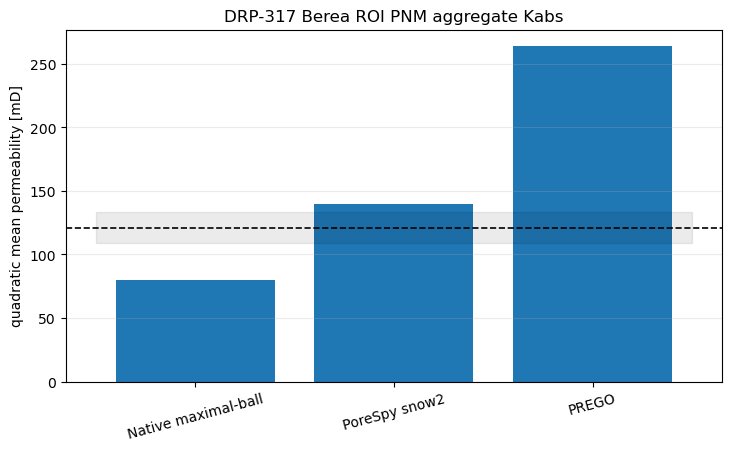

In [5]:
summary_plot_df = pnm_summary.copy()

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
ax.bar(
    summary_plot_df["backend_label"],
    summary_plot_df["aggregate_kabs_mD"],
    color="tab:blue",
)
ax.axhline(experimental_kabs_mD, color="black", linestyle="--", linewidth=1.2)
ax.fill_between(
    [-0.5, len(summary_plot_df) - 0.5],
    experimental_kabs_mD * (1.0 - experimental_kabs_rel_error),
    experimental_kabs_mD * (1.0 + experimental_kabs_rel_error),
    color="black",
    alpha=0.08,
)
ax.set_ylabel("quadratic mean permeability [mD]")
ax.set_title("DRP-317 Berea ROI PNM aggregate Kabs")
ax.grid(True, axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=15)

pnm_summary_plot_path = output_dir / "drp317_berea_roi_pnm_aggregate.png"
fig.savefig(pnm_summary_plot_path, dpi=200)
display(fig)
pnm_summary_plot_path

## Save comparison-ready tables

In [6]:
comparison_rows: list[dict[str, object]] = []
for row in pnm_directional.to_dict(orient="records"):
    comparison_rows.append(
        {
            "family": "extracted_pnm",
            "formulation": "pore_network_model",
            "method": row["backend_label"],
            "axis": row["axis"],
            "K_m2": float(row["k_m2"]),
            "K_mD": float(row["k_mD"]),
            "source": str(pnm_directional_path),
        }
    )

for axis in axis_order:
    comparison_rows.append(
        {
            "family": "experimental",
            "formulation": "bulk_experiment",
            "method": "Experimental Kabs",
            "axis": axis,
            "K_m2": experimental_kabs_mD * M2_PER_MD,
            "K_mD": experimental_kabs_mD,
            "source": "DRP-317 reference table",
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_path = output_dir / "drp317_berea_roi_pnm_comparison.csv"
summary_path = output_dir / "drp317_berea_roi_pnm_summary.csv"
input_summary_path = output_dir / "drp317_berea_roi_input_summary.csv"

comparison_df.to_csv(comparison_path, index=False)
pnm_summary.to_csv(summary_path, index=False)
input_summary.to_csv(input_summary_path, index=False)

pd.DataFrame(
    {
        "saved_path": [
            str(comparison_path),
            str(summary_path),
            str(input_summary_path),
            str(pnm_plot_path),
            str(pnm_summary_plot_path),
        ]
    }
)

,saved_path
0,/Users/dtvolpatto/Work/voids/notebooks/outputs...
1,/Users/dtvolpatto/Work/voids/notebooks/outputs...
2,/Users/dtvolpatto/Work/voids/notebooks/outputs...
3,/Users/dtvolpatto/Work/voids/notebooks/outputs...
4,/Users/dtvolpatto/Work/voids/notebooks/outputs...


## Interpretation notes

- These are the same PNM values already generated for the DRP-317 Berea
  validation notebook, not a new extraction.
- The PoreSpy aggregate is close to the experimental target for this ROI,
  while PREGO is high and the native maximal-ball backend is low.
- Notebook 41 compares these extracted-network rows against map-based
  Darcy-Darcy and Darcy-Brinkman micro-continuum FEM rows on the same ROI.